# 02: Test whether ligand-receptor reinforcement predicts synergy

Loads `results_combined_0.1filter.csv`, the per-combo table written by notebook 01
that pairs each ligand-pair combo with (a) its directional reinforcement scores --
whether each ligand's single-ligand effect moves its partner's receptor gene(s)
(`lfc_mean_1to2`/`lfc_mean_2to1`, combined into `lfc_mean_sum`, and flagged
`sig_flag_final` when reinforcing) -- and (b) its synergy gene counts from the GLM
interaction scoring (`n_synergy_positive`, `n_synergy_negative`, `n_buffering`, and
their rates as a fraction of `n_total_degs`, the number of genes significantly DE in
that combo at all).

After collapsing duplicate ligand-pair orientations into unordered pairs, this
notebook asks whether reinforcing combos (`sig_flag_final`) show more synergy than
non-reinforcing ones, and whether the strength of reinforcement
(`lfc_mean_sum`) correlates with the synergy rate, via:

1. **Wilcoxon / Mann-Whitney group tests**: `sig_flag_final` vs each of 5
   `GROUP_METRICS` (`freq_synergy_positive`, `freq_synergy_negative`,
   `freq_synergy_total`, `freq_buffering`, `n_total_degs`), BH-corrected across the 5.
2. **Spearman correlation**: `lfc_mean_sum` vs the same 5 metrics, BH-corrected
   across the 5.
3. **Permutation null**: for each of the 5 metrics, shuffle ligand->receptor-gene
   identity via a random bijection, 5000x, recompute `lfc_mean_sum`, collapse to
   unordered pairs, and calculate an empirical p-value against the resulting null
   distribution of Spearman correlations.
4. **Figures**: one combined, 4-column grid figure per plot type -- boxplots (by
   `sig_flag_final`), scatters (vs `lfc_mean_sum`), and permutation-null histograms,
   one panel per metric -- 3 PDFs total in `figures/`.


## Setup

In [1]:
# Repo-relative paths: inputs from imports_stable/, outputs to analysis_outs/
import os
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/02_combinatorial_screen_signalseq_SIG13"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import os

import cnsplots as cns
cns.settings.panel_label_fontname = "sans serif"

FILTER = '0.1filter'
OUT_DIR = f'{OUTS_DIR}/signal_reinforcement_lfc_mean'
FIG_DIR = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)

RESULTS_CSV = f'{IMPORTS_DIR}/SIG13/analysis_outs/signal_reinforcement_lfc_mean/results_combined_0.1filter.csv'
MAP_CSV = 'ligand_receptor_map.csv'
SCORED_CSV = f'{IMPORTS_DIR}/SIG13/analysis_outs/glmGamPoi/interactions_scored_v3_glmGamPoi_{FILTER}.csv'

REINF_METRIC = 'lfc_mean_sum'
GROUP_METRICS = ['freq_synergy_positive', 'freq_synergy_negative', 'freq_synergy_total',
                  'freq_buffering', 'n_total_degs']

N_PERM = 5000
RNG_SEED = 0
EPS = 1e-300

sns.set_theme(style='ticks')


## Load the combined results table from notebook 01

In [2]:
raw = pd.read_csv(RESULTS_CSV)
print(f'{len(raw)} combos loaded from notebook 01 (consistent_ligands, real, non-self, expect 138)')
print(f'{raw["lfc_mean_sum"].notna().sum()} of these have >=1 scored reinforcement direction')

138 combos loaded from notebook 01 (consistent_ligands, real, non-self, expect 138)
138 of these have >=1 scored reinforcement direction


## Collapse duplicate-orientation pairs

Some ligand pairs appear twice in `raw` under both round1/round2 assignments (e.g.
`IL2_IL4` and `IL4_IL2`) -- two independent replicate measurements of the same
biological pair, not two conditions. Every subsequent section works with one row per
*unordered* ligand pair.

To collapse without losing directional meaning, each pair is first re-expressed in a
canonical orientation: `ligand1` = whichever of the two ligands sorts first
alphabetically, `ligand2` = the other, and the `_1to2`/`_2to1`-suffixed columns are
swapped for any row where the original `ligand1`/`ligand2` didn't already match that
order. Rows for the same pair are then averaged: numeric metrics (`lfc_mean`,
`n_receptor_genes_scored`) by mean; boolean flags (`sig_flag`,
`uses_shared_subunit_only`, `has_*_data`) by OR (true if either replicate showed it);
receptor-gene-scored strings by set union; synergy/DEG counts and rates by mean.

After collapsing, `lfc_mean_sum` and `sig_flag_final` are recomputed from the
collapsed `_1to2`/`_2to1` columns rather than averaged/OR'd directly, because
collapsing changes which rows contribute to each per-direction value -- so these two
summary columns have to be derived fresh from the collapsed data, not merged as-is.

`n_orientations` (1 or 2) and `orientations` (the pre-collapse `interaction` name(s)
that were merged into this row) are kept for provenance.


In [3]:
def canonical_pair_name(interaction):
    """'IL4_IL2' -> 'IL2_IL4' (alphabetically sorted); used both to collapse `raw`
    below and to collapse the permutation null's per-orientation scores."""
    a, b = interaction.split('_', 1)
    lo, hi = sorted([a, b])
    return f'{lo}_{hi}'


DIRECTIONAL_NUMERIC = ['lfc_mean', 'n_receptor_genes_scored']
DIRECTIONAL_BOOL = ['sig_flag', 'uses_shared_subunit_only']
DIRECTIONAL_STR = ['receptor_genes_scored']
AVERAGED_COUNT_METRICS = ['n_total_degs', 'n_synergy_positive', 'n_synergy_negative', 'n_buffering', 'n_synergy_total',
                          'freq_synergy_positive', 'freq_synergy_negative', 'freq_synergy_total', 'freq_buffering']

lo = raw[['ligand1', 'ligand2']].min(axis=1)
is_reversed = raw['ligand1'] != lo
print(f'{is_reversed.sum()} / {len(raw)} rows are in reversed order relative to the canonical alphabetical pair; '
      f'{raw.loc[is_reversed, "interaction"].map(canonical_pair_name).nunique()} distinct pairs affected')

canon = raw.copy()
# sig_flag/uses_shared_subunit_only/has_*_data can hold NaN (direction unscored) mixed
# with True/False, so force object dtype before swapping -- otherwise assigning NaN
# into a column pandas happened to infer as pure bool raises a FutureWarning.
for col in [f'{s}_{d}' for s in DIRECTIONAL_BOOL for d in ('1to2', '2to1')] + ['has_1to2_data', 'has_2to1_data']:
    canon[col] = canon[col].astype('object')
for suffix in DIRECTIONAL_NUMERIC + DIRECTIONAL_BOOL + DIRECTIONAL_STR:
    a_col, b_col = f'{suffix}_1to2', f'{suffix}_2to1'
    a_vals, b_vals = raw[a_col].copy(), raw[b_col].copy()
    canon.loc[is_reversed, a_col] = b_vals[is_reversed]
    canon.loc[is_reversed, b_col] = a_vals[is_reversed]
a_has, b_has = raw['has_1to2_data'].copy(), raw['has_2to1_data'].copy()
canon.loc[is_reversed, 'has_1to2_data'] = b_has[is_reversed]
canon.loc[is_reversed, 'has_2to1_data'] = a_has[is_reversed]
canon['pair_key'] = raw['interaction'].map(canonical_pair_name)


def collapse_group(g):
    row = {'interaction': g.name}
    row['ligand1'], row['ligand2'] = g.name.split('_', 1)
    row['n_orientations'] = len(g)
    row['orientations'] = ';'.join(sorted(g['interaction']))
    for suffix in DIRECTIONAL_NUMERIC:
        for d in ('1to2', '2to1'):
            row[f'{suffix}_{d}'] = g[f'{suffix}_{d}'].mean(skipna=True)
    for suffix in DIRECTIONAL_BOOL:
        for d in ('1to2', '2to1'):
            col = f'{suffix}_{d}'
            vals = g[col].astype('object').where(g[col].notna(), False).astype(bool)
            row[col] = bool(vals.any())
    for suffix in DIRECTIONAL_STR:
        for d in ('1to2', '2to1'):
            col = f'{suffix}_{d}'
            genes = set()
            for v in g[col].dropna():
                genes.update(v.split(';'))
            row[col] = ';'.join(sorted(genes)) if genes else np.nan
    for col in ('has_1to2_data', 'has_2to1_data'):
        vals = g[col].astype('object').where(g[col].notna(), False).astype(bool)
        row[col] = bool(vals.any())
    for col in AVERAGED_COUNT_METRICS:
        row[col] = g[col].mean(skipna=True)
    return pd.Series(row)


merged = canon.groupby('pair_key').apply(collapse_group, include_groups=False).reset_index(drop=True)
print(f'{len(raw)} per-orientation combo rows collapsed to {len(merged)} unordered ligand pairs '
      f'({int((merged["n_orientations"] == 2).sum())} pairs had both orientations tested)')

merged['lfc_mean_sum'] = np.nanmean(
    np.vstack([merged['lfc_mean_1to2'].values, merged['lfc_mean_2to1'].values]), axis=0)

sig_1to2 = merged['sig_flag_1to2'].astype(bool)
sig_2to1 = merged['sig_flag_2to1'].astype(bool)
merged['sig_flag_final'] = (sig_1to2 | sig_2to1) & (merged['lfc_mean_sum'] > 0)
# sig_flag_final stays boolean (used by mannwhitney_group_test); string copy for plot axes/legends
merged['reinforcing_label'] = merged['sig_flag_final'].map({True: 'yes', False: 'no'})

merged.to_csv(f'{OUT_DIR}/merged_collapsed_{FILTER}.csv', index=False)
merged.head()


72 / 138 rows are in reversed order relative to the canonical alphabetical pair; 72 distinct pairs affected
138 per-orientation combo rows collapsed to 110 unordered ligand pairs (28 pairs had both orientations tested)


,interaction,ligand1,ligand2,n_orientations,orientations,lfc_mean_1to2,lfc_mean_2to1,n_receptor_genes_scored_1to2,n_receptor_genes_scored_2to1,sig_flag_1to2,...,n_synergy_negative,n_buffering,n_synergy_total,freq_synergy_positive,freq_synergy_negative,freq_synergy_total,freq_buffering,lfc_mean_sum,sig_flag_final,reinforcing_label
0,CCL19_IFNG,CCL19,IFNG,1,IFNG_CCL19,-0.134862,-0.140660,2.0,1.0,False,...,8.0,59.0,15.0,0.003806,0.004350,0.008157,0.032083,-0.137761,False,no
1,CCL19_IL2,CCL19,IL2,1,IL2_CCL19,-0.017600,-0.557364,2.0,1.0,False,...,102.0,135.0,187.0,0.014434,0.017320,0.031754,0.022924,-0.287482,False,no
2,CCL19_IL21,CCL19,IL21,1,IL21_CCL19,-0.022730,0.165095,1.0,1.0,False,...,235.0,72.0,413.0,0.033827,0.044660,0.078487,0.013683,0.071182,True,yes
3,CCL19_IL27,CCL19,IL27,1,IL27_CCL19,0.352033,-0.262731,1.0,1.0,True,...,21.0,25.0,26.0,0.001528,0.006416,0.007944,0.007638,0.044651,True,yes
4,CCL19_IL4,CCL19,IL4,1,IL4_CCL19,-0.123892,-0.256560,1.0,1.0,False,...,56.0,185.0,74.0,0.003970,0.012351,0.016321,0.040803,-0.190226,False,no


## Load the ligand->receptor map and single-ligand DEG hits

Needed for the permutation null.


In [4]:
rmap = pd.read_csv(MAP_CSV)
rmap_avail = rmap[rmap['in_gene_panel']].copy()
receptor_genes = set(rmap_avail['receptor_gene'])
consistent_combos = set(raw['interaction'])

usecols = ['name', 'interaction', 'lfc_ligand1', 'adj_pval_ligand1', 'lfc_ligand2', 'adj_pval_ligand2']
chunks = []
for chunk in pd.read_csv(SCORED_CSV, usecols=usecols, chunksize=500_000):
    sub = chunk[chunk['name'].isin(receptor_genes) & chunk['interaction'].isin(consistent_combos)]
    if len(sub):
        chunks.append(sub)
hits = pd.concat(chunks, ignore_index=True)
split = hits['interaction'].str.split('_', n=1, expand=True)
hits['ligand1'], hits['ligand2'] = split[0], split[1]
print(f'{len(hits)} receptor-gene rows loaded for {len(consistent_combos)} consistent_ligands combos')


4554 receptor-gene rows loaded for 138 consistent_ligands combos


## Helper functions

Defined once, reused across every section below:
- `correlation_grid` -- Spearman r for every (x, y) metric pair, BH-corrected as one
  test family. Called here as a 1x5 grid (`REINF_METRIC` vs the 5 `GROUP_METRICS`).
- `mannwhitney_group_test` -- two-sided Mann-Whitney U between the `True`/`False`
  levels of a boolean column (`sig_flag_final`).
- `scatter_and_export` / `boxplot_and_export` -- make a figure, save it as PDF, and
  export the exact per-combo data behind it. Grouping/hue column is `reinforcing_label`
  (`'yes'`/`'no'` string copy of `sig_flag_final`, True = reinforcing combo).


In [5]:
CONTEXT_COLS = [
    'interaction', 'ligand1', 'ligand2', 'n_orientations', 'orientations',
    'sig_flag_1to2', 'sig_flag_2to1', 'sig_flag_final', 'reinforcing_label',
    'lfc_mean_1to2', 'lfc_mean_2to1',
    'receptor_genes_scored_1to2', 'receptor_genes_scored_2to1',
    'uses_shared_subunit_only_1to2', 'uses_shared_subunit_only_2to1',
    'n_total_degs', 'n_synergy_positive', 'n_synergy_negative', 'n_synergy_total', 'n_buffering',
    'freq_synergy_positive', 'freq_synergy_negative', 'freq_synergy_total', 'freq_buffering',
]


def correlation_grid(df, x_metrics, y_metrics, min_n=5):
    """Spearman r for every x_metric x y_metric pair, BH-corrected across the family."""
    rows = []
    for rm in x_metrics:
        for sm in y_metrics:
            sub = df[[rm, sm]].dropna()
            if len(sub) < min_n:
                continue
            r, p = spearmanr(sub[rm], sub[sm])
            rows.append({'reinforcement_metric': rm, 'group_metric': sm, 'n': len(sub), 'spearman_r': r, 'p_value': p})
    out = pd.DataFrame(rows)
    out['p_adj_bh'] = multipletests(out['p_value'], method='fdr_bh')[1]
    return out.sort_values('p_adj_bh')


def mannwhitney_group_test(df, group_col, value_col, alternative='two-sided'):
    """Two-sided Mann-Whitney U comparing value_col between the True/False levels of
    boolean group_col."""
    a = df.loc[df[group_col] == True, value_col].dropna()
    b = df.loc[df[group_col] == False, value_col].dropna()
    if len(a) < 2 or len(b) < 2:
        return None
    stat, p = mannwhitneyu(a, b, alternative=alternative)
    return {'metric': value_col, 'n_true': len(a), 'n_false': len(b),
            'median_true': a.median(), 'median_false': b.median(), 'U': stat, 'p_value': p}


def grid_axes(n, ncols=5, subplot_size=(4, 4)):
    """nrows x ncols grid of axes for n plots, extra axes hidden."""
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(subplot_size[0] * ncols, subplot_size[1] * nrows), squeeze=False)
    flat = axes.flatten()
    for ax in flat[n:]:
        ax.set_visible(False)
    return fig, flat[:n]


def scatter_and_export(ax, xcol, ycol, fname, title=None, legend=True):
    """Scatter xcol vs ycol (colored by reinforcing_label) into `ax`, and export the
    comprehensive per-combo data behind it."""
    cols = list(dict.fromkeys(CONTEXT_COLS + [xcol, ycol]))
    plot_df = merged[cols].dropna(subset=[xcol, ycol])
    plot_df.to_csv(f'{OUT_DIR}/scatter_data_{fname}_{FILTER}.csv', index=False)

    sns.scatterplot(data=plot_df, x=xcol, y=ycol, hue='reinforcing_label', ax=ax,
                     palette=['#666666FF', '#E6AB02FF'], legend=legend)
    r, p = spearmanr(plot_df[xcol], plot_df[ycol])
    ax.set_title(title or f'{xcol} vs {ycol}\nSpearman r={r:.2f}, p={p:.1e}, n={len(plot_df)}')
    return plot_df

## 1. Wilcoxon / Mann-Whitney group tests

Two-sided Mann-Whitney U: `sig_flag_final` (reinforcing vs non-reinforcing) vs each of the 5 `GROUP_METRICS`, BH-corrected across the 5.


In [6]:
group_rows = [mannwhitney_group_test(merged, 'sig_flag_final', m) for m in GROUP_METRICS]
group_df = pd.DataFrame([r for r in group_rows if r is not None]).rename(
    columns={'metric': 'group_metric', 'n_true': 'n_reinforcing', 'n_false': 'n_non_reinforcing',
             'median_true': 'median_reinforcing', 'median_false': 'median_non_reinforcing'})
group_df['p_adj_bh'] = multipletests(group_df['p_value'], method='fdr_bh')[1]
group_df.to_csv(f'{OUT_DIR}/wilcoxon_group_comparison_{FILTER}.csv', index=False)
group_df


,group_metric,n_reinforcing,n_non_reinforcing,median_reinforcing,median_non_reinforcing,U,p_value,p_adj_bh
0,freq_synergy_positive,38,72,0.031099,0.009849,2191.0,2.338488e-07,5.846220e-07
1,freq_synergy_negative,38,72,0.033941,0.009918,2145.0,1.055267e-06,1.758779e-06
2,freq_synergy_total,38,72,0.066081,0.021384,2219.0,8.981872e-08,4.490936e-07
3,freq_buffering,38,72,0.070138,0.048708,1599.0,1.473622e-01,1.473622e-01
4,n_total_degs,38,72,5357.500000,4282.500000,1971.5,1.503820e-04,1.879775e-04


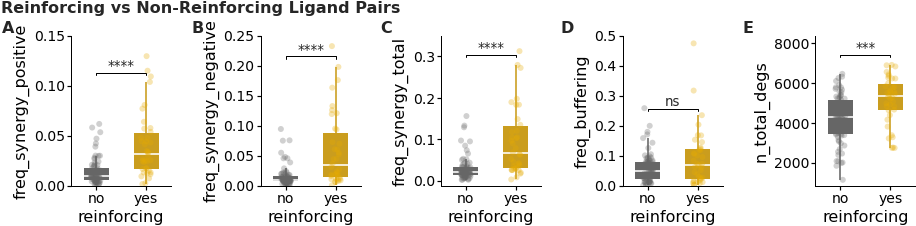

In [7]:
mp = cns.multipanel(max_width=1000, title="Reinforcing vs Non-Reinforcing Ligand Pairs",
                     title_fontweight="bold", loc="left")
for m in GROUP_METRICS:
    mp.panel(None, 50, 75)
    box_df = merged[['reinforcing_label', m]].dropna()
    ax = cns.boxplot(data=box_df, x='reinforcing_label', y=m, hue='reinforcing_label',
                     legend=False, palette=['#666666FF', '#E6AB02FF'], pairs=[("no", "yes")])
    cns.stripplot(data=box_df, x='reinforcing_label', y=m, hue='reinforcing_label', ax=ax,
                   palette=['#666666FF', '#E6AB02FF'], size=3, alpha=0.3, showmedian=False)
    if m == "freq_synergy_positive":
        ax.set_ylim(0, 0.15)
    if m == "freq_synergy_negative":
        ax.set_ylim(0, 0.25)
    if m == "freq_buffering":
        ax.set_ylim(0, 0.5)
    ax.set_xlabel(f'reinforcing')
cns.savefig(f'{FIG_DIR}/boxplots_combined_{FILTER}.pdf')

## 2. Spearman correlation

`lfc_mean_sum` vs each of the 5 `GROUP_METRICS`, BH-corrected across the 5.


In [8]:
spearman_df = correlation_grid(merged, [REINF_METRIC], GROUP_METRICS)
spearman_df.to_csv(f'{OUT_DIR}/spearman_correlation_{FILTER}.csv', index=False)
spearman_df


,reinforcement_metric,group_metric,n,spearman_r,p_value,p_adj_bh
0,lfc_mean_sum,freq_synergy_positive,110,0.378653,0.000045,0.000209
2,lfc_mean_sum,freq_synergy_total,110,0.366111,0.000084,0.000209
1,lfc_mean_sum,freq_synergy_negative,110,0.301238,0.001384,0.002277
4,lfc_mean_sum,n_total_degs,110,0.294038,0.001821,0.002277
3,lfc_mean_sum,freq_buffering,110,0.084922,0.377728,0.377728


## 3. Permutation null

Tests each of the 5 `GROUP_METRICS` against a null where receptor-gene identity is
randomly reassigned across ligands (a random bijection over the ligand set --
preserves the overall shape of the map but breaks the true correspondence between a
specific ligand and its real receptor). 5000 permutations per metric; empirical

$p = \frac{1 + \#\{|r_{\text{null}}| \geq |r_{\text{obs}}|\}}{1 + n_{\text{perms}}}$

`compute_combined_metric` recomputes the same directional reinforcement score as the
`lfc_mean_sum` column loaded above -- for each direction, averaging the `lfc` of
the acting ligand on the partner's receptor gene(s), then averaging the two
directions together -- so it can be re-run cheaply on a shuffled ligand->receptor map
inside the permutation loop. Its output is collapsed to unordered pairs with
`canonical_pair_name` (mean across orientations, same as the main collapse above)
before joining against `merged`, so the permutation null tests the same n as every
other section. Run once per metric (5 metrics x 5000 permutations each), not just
top-K headline pairs.


In [9]:
def compute_combined_metric(hits_df, rmap_df):
    """Recompute the directional reinforcement score (raw `lfc` metric, mean subunit
    aggregation) for a given ligand->receptor mapping, so it can be re-run per
    permutation on a shuffled mapping."""
    def one_dir(target_col, lfc_col):
        m = hits_df.merge(rmap_df, left_on=[target_col, 'name'], right_on=['ligand', 'receptor_gene'], how='inner')
        return m.groupby('interaction')[lfc_col].mean()
    a = one_dir('ligand2', 'lfc_ligand1')
    b = one_dir('ligand1', 'lfc_ligand2')
    return pd.concat([a, b], axis=1).mean(axis=1, skipna=True)


ligands = sorted(rmap_avail['ligand'].unique())
rng = np.random.RandomState(RNG_SEED)

perm_results = []
null_traces = {}
for m in GROUP_METRICS:
    observed_scores = compute_combined_metric(hits, rmap_avail)
    observed_scores = observed_scores.groupby(canonical_pair_name).mean()
    obs_df = merged.set_index('interaction').join(observed_scores.rename('reinforcement')).dropna(subset=['reinforcement', m])
    obs_r, _ = spearmanr(obs_df['reinforcement'], obs_df[m])

    null_r = np.empty(N_PERM)
    for i in range(N_PERM):
        perm = rng.permutation(ligands)
        mapping = dict(zip(ligands, perm))
        permuted = rmap_avail.copy()
        permuted['ligand'] = permuted['ligand'].map(mapping)
        perm_scores = compute_combined_metric(hits, permuted)
        perm_scores = perm_scores.groupby(canonical_pair_name).mean()
        pdf_ = merged.set_index('interaction').join(perm_scores.rename('reinforcement')).dropna(subset=['reinforcement', m])
        null_r[i], _ = spearmanr(pdf_['reinforcement'], pdf_[m])

    emp_p = (1 + np.sum(np.abs(null_r) >= np.abs(obs_r))) / (1 + N_PERM)
    perm_results.append({'group_metric': m, 'observed_r': obs_r,
                          'null_mean': null_r.mean(), 'null_sd': null_r.std(), 'empirical_p': emp_p})
    null_traces[m] = null_r

perm_df = pd.DataFrame(perm_results)
perm_df.to_csv(f'{OUT_DIR}/permutation_null_{FILTER}.csv', index=False)
perm_df

,group_metric,observed_r,null_mean,null_sd,empirical_p
0,freq_synergy_positive,0.378653,-0.029369,0.139779,0.004599
1,freq_synergy_negative,0.301238,-0.019850,0.138308,0.029994
2,freq_synergy_total,0.366111,-0.023055,0.139655,0.008398
3,freq_buffering,0.084922,-0.063058,0.140015,0.597081
4,n_total_degs,0.294038,-0.037708,0.134549,0.035593


## 4. Figures

One combined figure per plot type (boxplots, scatters, permutation-null
histograms), each laid out as a grid with 4 columns, one panel per `GROUP_METRIC` --
3 PDFs total, exported to `figures/`.


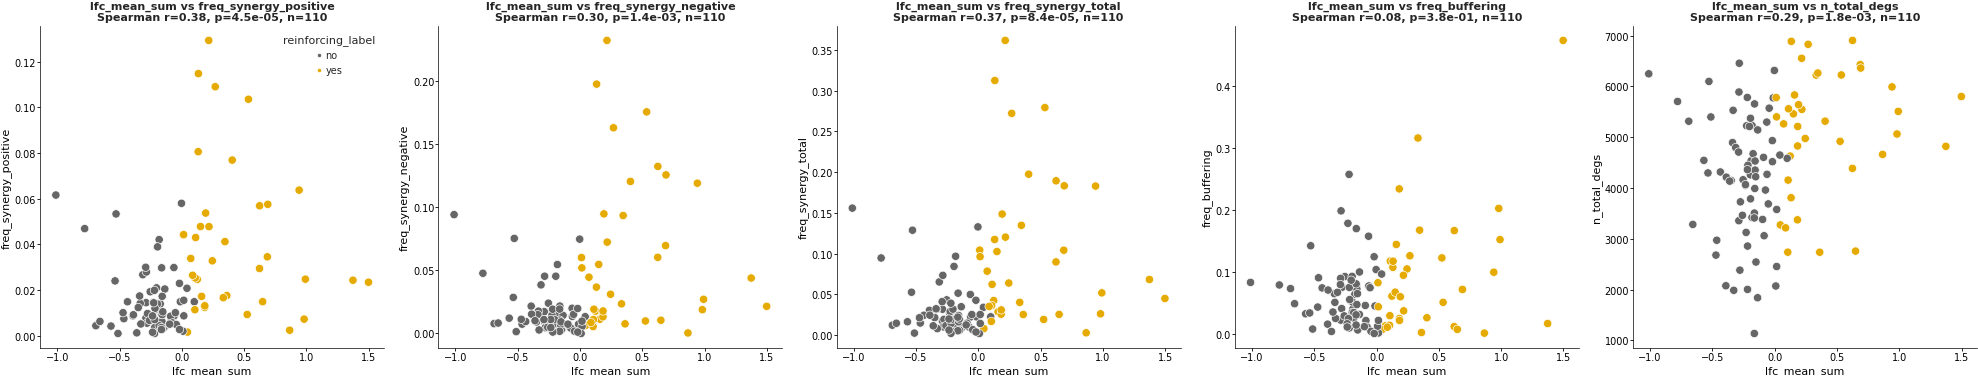

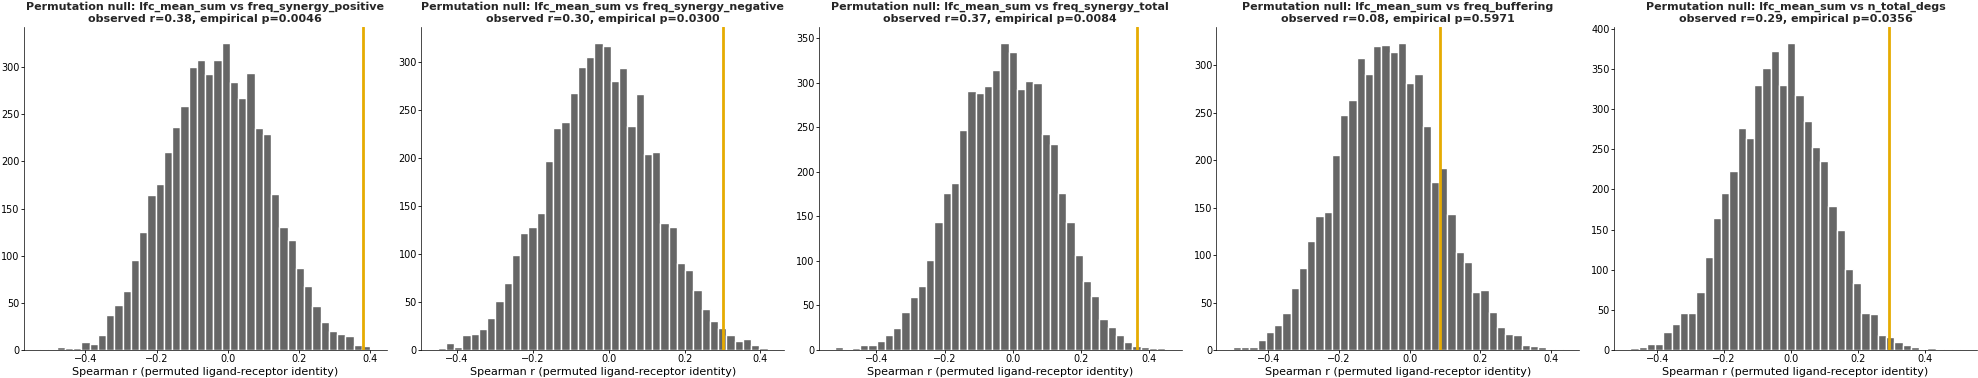

In [10]:
fig, axes = grid_axes(len(GROUP_METRICS), subplot_size=(4, 4))
for ax, m in zip(axes, GROUP_METRICS):
    scatter_and_export(ax, REINF_METRIC, m, f'scatter_{m}', legend=(m == GROUP_METRICS[0]))
sns.despine(fig)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/scatters_combined_{FILTER}.pdf')
plt.show()

fig, axes = grid_axes(len(GROUP_METRICS), subplot_size=(4, 4))
for ax, m in zip(axes, GROUP_METRICS):
    null_r = null_traces[m]
    obs_row = perm_df[perm_df['group_metric'] == m].iloc[0]
    ax.hist(null_r, bins=40, color='#666666FF', edgecolor='white')
    ax.axvline(obs_row['observed_r'], color='#E6AB02FF', linewidth=2)
    ax.set_title(f'Permutation null: {REINF_METRIC} vs {m}\nobserved r={obs_row["observed_r"]:.2f}, empirical p={obs_row["empirical_p"]:.4f}')
    ax.set_xlabel('Spearman r (permuted ligand-receptor identity)')
sns.despine(fig)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/permutation_nulls_combined_{FILTER}.pdf')
plt.show()
